#### Capstone Project

**THE PRICE IS RIGHT**

-> 1. **Data Curation**

2. Data Pre-Processing

3. Evaluation against Baselines and Traditional ML

4. Deep Learning and LLMs

5. Fine-Tuning a Frontier Model

The dataset is here:
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023

And the folder with all the product datasets is here:
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/tree/main/raw/meta_categories

In [ ]:
# %pip install datasets==3.6.0

# also this is similar using uv:  `!uv add --upgrade datasets==3.6.0`

In [ ]:
# to set path for high level folders

import os
import sys

sys.path.insert(0, os.path.abspath(".."))           # put the parent folder .. at 0th index for high priorty

In [158]:
# imports

import os
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm                  # progress bar suitable for notebook environment
import numpy as np
import random
from pricer.parser import parse                 # to clean each datapoint in the dataset individually

from pricer.loaders import ItemLoader           # to load the entire dataset belonging to multiple categories using multi-processing and standardize the datapoints using parser package above

from pricer.items import Item                   # to push the curated data into HuggingFace Hub


load_dotenv(override=True)                      # to load hf_token

True

In [ ]:
# to login to huggingface

hf_token = os.getenv('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

# add_to_git_credential = True is set for git access. Helps when cloning or fetching without explicity hf_token

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [ ]:
# load the dataset

dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_Appliances", split="full", trust_remote_code=True)

''' 
`split = "full"`     - indicates not to split the data into train/validate/split but return the entire data as single dataset object
'''

README.md:   0%|          | 0.00/30.3k [00:00<?, ?B/s]

Amazon-Reviews-2023.py:   0%|          | 0.00/39.6k [00:00<?, ?B/s]

raw/meta_categories/meta_Appliances.json(…): reconstructing file:   0%|          |  0.00B /  285MB            

raw/meta_categories/meta_Appliances.json(…): downloading bytes:           |  0.00B            

Generating full split: 0 examples [00:00, ? examples/s]

In [ ]:
# count the total records loaded

print(f'Number of records in the dataset {len(dataset):,}')

Number of records in the dataset 94,327


In [19]:
# type of the data in the dataset and sample content

print(f'Type of the data {type(dataset[0])}')
print('\n--------------')
dataset[0]

Type of the data <class 'dict'>

--------------


{'main_category': 'Industrial & Scientific',
 'title': 'ROVSUN Ice Maker Machine Countertop, Make 44lbs Ice in 24 Hours, Compact & Portable Ice Maker with Ice Basket for Home, Office, Kitchen, Bar (Silver)',
 'average_rating': 3.7,
 'rating_number': 61,
 'features': ['【Quick Ice Making】This countertop ice machine creates crystal & bullet shaped ice cubes; 44lbs of ice ready in 24 hours, 12 cubes made per cycle within 10 mins; you can perfectly use it for drinks, wine, smoothies, food',
  '【Portable Design】The weight of this ice maker is only 23.3lbs, and the small size (10.63 x14.37 x 12.87)" makes it portable. It\'s compact feature is perfect for home, office, apartments, dormitories, RVs and more, it can be placed on countertop or tabletop, plug it anywhere you like',
  '【Simple Operation】Adding the water tank with purified water; Power on machine and press "on/off" button to start ice making process; After 8-12 minutes, ice cube will fall off into the ice basket automatically; Take 

In [23]:
# to see the most expensive item:

max_price = 0
max_price_item = None

for datapoint in tqdm(dataset):
    try:
        price = float(datapoint['price'])
        if price > max_price:
            max_price = price
            max_price_item = datapoint
    except ValueError:
        pass

print(f'The most expensive item is {max_price_item['title']} with price {max_price:,.2f}')

  0%|          | 0/94327 [00:00<?, ?it/s]

The most expensive item is TurboChef BULLET Rapid Cook Electric Microwave Convection Oven with price 21,095.62


In [34]:
# to parse the data points in the dataset such that 
# selecting the required features, converting all the units to pounds for weight and standardizing text by removing alpha numeric codes

items = [parse(datapoint, "Appliances") for datapoint in tqdm(dataset)]
items = [item for item in items if item is not None]
print(f'Successfully extracted {len(items):,} items from {len(dataset):,} datapoints')

  0%|          | 0/94327 [00:00<?, ?it/s]

Successfully extracted 35,307 items from 94,327 datapoints


In [42]:
# sample datapoint

print(items[0])

title='WD12X10327 Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces AP4980629 PS3486910 1811003' category='Appliances' price=8.99 full='Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces   1811003\n[\'【PARTS NUMBER】The  dishwasher top rack wheels and stud assembly Kit （4 pcs）\', \'【SCOPE OF 】The dishwasher works with most top name brands,If you are not sure if part is correct, ask us in Customer questions & answers section or visiting the AMI PARTS storefront.We’re happy to help ensure you select the correct part for your Rack Roller and stud\', \'【 PART】, , , , , , , , , , , , \', \'【FIXES SYMPTOMS】Door won’t close | Not cleaning dishes properly | Noisy | Door latch failure\', \'【QUALITY WARRANTY】The replacement part is made from durable high quality material and well-tested by manufacturer.For any reason you’re not satisfied,you can ask for a replacement or full refund\']\n{"Brand Name": "AMI PARTS", "Model Info": "", "Item Weight": "0.634 ounces", "Color

In [ ]:
# total attributes / features of sample datapoint

print(f'Product Title: {items[0].title}\n')
print(f'Product Category: {items[0].category}\n')
print(f'Product Price: {items[0].price}\n')
print(f'Product Full Description: {items[0].full}\n')
print(f'Product Weight: {items[0].weight}')

Product Title: WD12X10327 Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces AP4980629 PS3486910 1811003

Product Category: Appliances

Product Price: 8.99

Product Full Description: Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces   1811003
['【PARTS NUMBER】The  dishwasher top rack wheels and stud assembly Kit （4 pcs）', '【SCOPE OF 】The dishwasher works with most top name brands,If you are not sure if part is correct, ask us in Customer questions & answers section or visiting the AMI PARTS storefront.We’re happy to help ensure you select the correct part for your Rack Roller and stud', '【 PART】, , , , , , , , , , , , ', '【FIXES SYMPTOMS】Door won’t close | Not cleaning dishes properly | Noisy | Door latch failure', '【QUALITY WARRANTY】The replacement part is made from durable high quality material and well-tested by manufacturer.For any reason you’re not satisfied,you can ask for a replacement or full refund']
{"Brand Name": "AMI PARTS", "Model Info": "", "It

In [ ]:
# to plot a simple histogram of total datapoints having certain number of characters in it's full summary

prices = [item.price for item in items]
lengths = [len(item.full) for item in items]

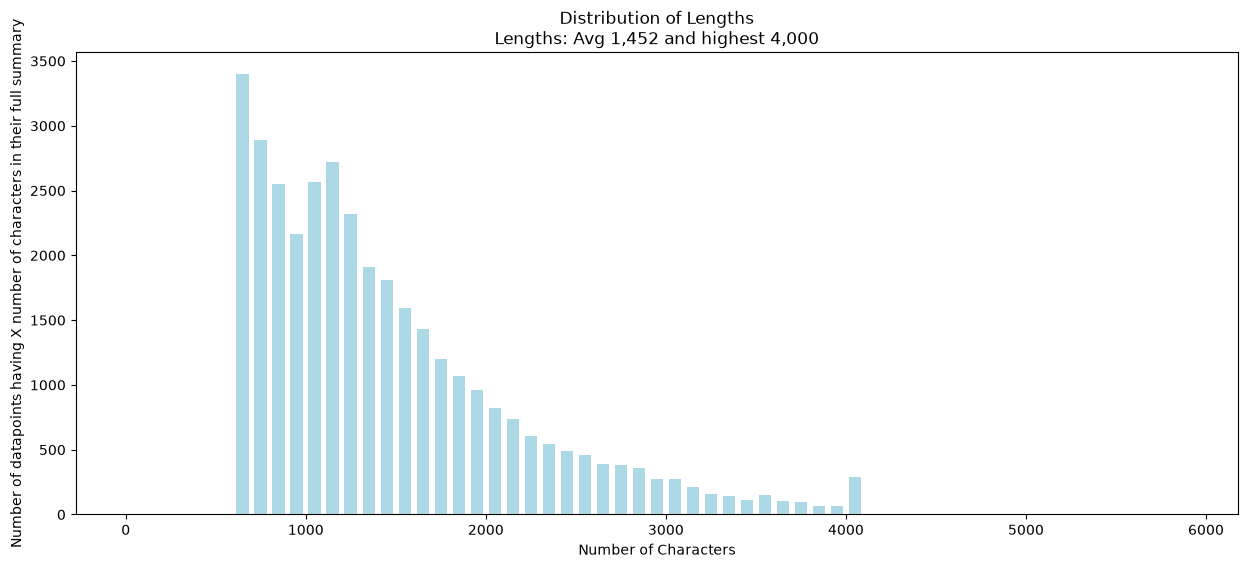

In [ ]:
# histogram (distribution of lengths)
# Note: We have limited the number of characters in a full summary for each product to 4000 chars only

plt.figure(figsize=(15,6))      # width and height in inches
plt.title(f'Distribution of Lengths\nLengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,.0f}')
plt.xlabel('Number of Characters')
plt.ylabel('Number of datapoints having X number of characters in their full summary')
plt.hist(lengths, rwidth=0.7, color='lightblue', bins=range(0,6000,100))
plt.show()

# rwidth = 0.7 indicates the bars to take 70% of the space allocated for each bin.
# this brings the space between each bar in the histogram

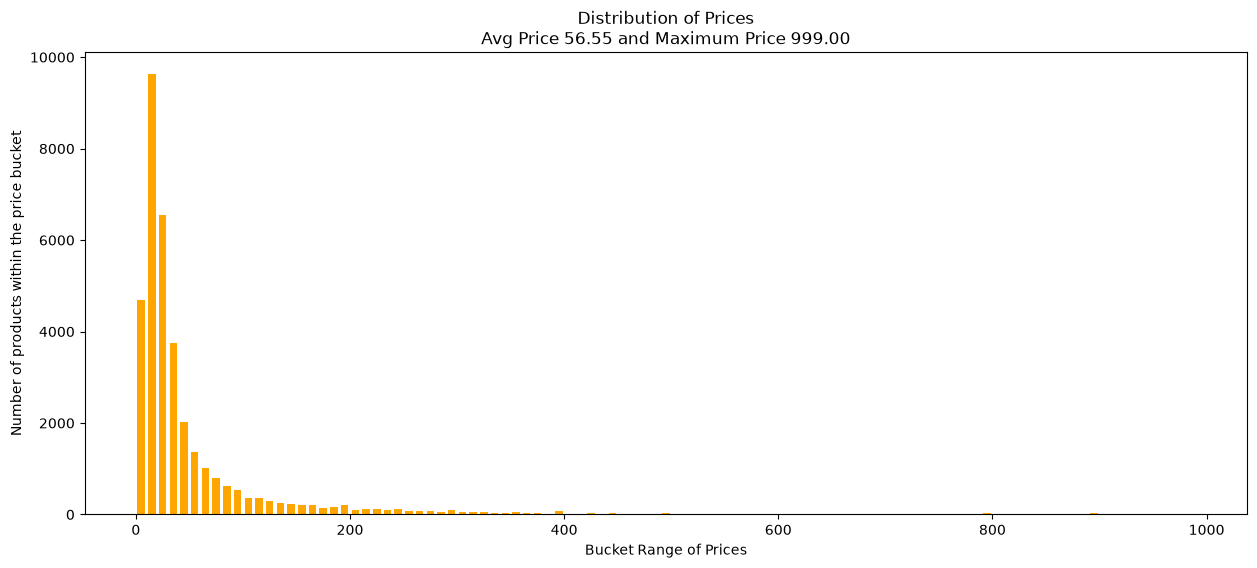

In [55]:
# histogram (distribution of prices)
# Note: We have limited the product prices from 0.5 to 999.5

plt.figure(figsize=(15,6))
plt.title(f'Distribution of Prices\nAvg Price {sum(prices)/len(prices):,.2f} and Maximum Price {max(prices):,.2f}')
plt.xlabel('Bucket Range of Prices')
plt.ylabel('Number of products within the price bucket')
plt.hist(prices, rwidth=0.7, color='orange', bins=range(0,1000,10))
plt.show()

In [ ]:
# To extract the full summary of the product with maximum number of characters

max_length = max(lengths)                                   # returns the max number from lengths
item_with_max_chars = items[lengths.index(max_length)].full
print(item_with_max_chars)

Polyester Dryer Vent Filters Replacement Part by Beaquicy Replacement for Better vent Indoor Dryer Vent Packs of 12
['✅【 AIR 】--- The polyester filters provide optimal air conditioning for your dryer and keep it away from polluted air. Because these parts will rate to trap fine lint and dust particles, protect your home from unwanted bacteria and other unfriendly dust particles and can be vacuumed clean or replaced when fully loaded with lint. so that the air in your room is cleaner than ever. While protecting your indoor quality, clothes can dry faster. It helps improve the indoor air quality.', '✅【HIGH-GRADE 】--- The package includes 12 x replacement polyester filters for bettervent.They are well-made from durable and high-grade polyester which can traps fine lint and dust particles, optimize the cleaning process and prolong lifetime. Each filter protects up to 5 dryer loads! For best results insert blue side facing towards dryer vent.', '✅【WIDE 】--- These polyester filters are desig

In [121]:
# using ItemLoader to load the dataset using multi-processing and then parsing using parser package

loader = ItemLoader('Appliances')               # ItemLoader class
items = loader.load()                           # load method belonging to ItemLoader class

Loading dataset Appliances


100%|██████████| 95/95 [00:03<00:00, 25.60it/s]


Completed Appliances with 35,307 datapoints in 0.1 mins


In [89]:
# total datapoints loaded from Appliances dataset using ItemLoader.load() method

print(f'Total Datapoints loaded from Appliances category {len(items):,}')

Total Datapoints loaded from Appliances category 35,307


In [66]:
# sample datapoint

print(items[0])

title='WD12X10327 Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces AP4980629 PS3486910 1811003' category='Appliances' price=8.99 full='Rack Roller and stud assembly Kit (4 Pack) by AMI PARTS Replaces   1811003\n[\'【PARTS NUMBER】The  dishwasher top rack wheels and stud assembly Kit （4 pcs）\', \'【SCOPE OF 】The dishwasher works with most top name brands,If you are not sure if part is correct, ask us in Customer questions & answers section or visiting the AMI PARTS storefront.We’re happy to help ensure you select the correct part for your Rack Roller and stud\', \'【 PART】, , , , , , , , , , , , \', \'【FIXES SYMPTOMS】Door won’t close | Not cleaning dishes properly | Noisy | Door latch failure\', \'【QUALITY WARRANTY】The replacement part is made from durable high quality material and well-tested by manufacturer.For any reason you’re not satisfied,you can ask for a replacement or full refund\']\n{"Brand Name": "AMI PARTS", "Model Info": "", "Item Weight": "0.634 ounces", "Color

In [67]:
# similarly to load the datasets belonging to different categories

dataset_names = [
    "Automotive",
    "Electronics",
    "Office_Products",
    "Tools_and_Home_Improvement",
    "Cell_Phones_and_Accessories",
    "Toys_and_Games",
    "Appliances",
    "Musical_Instruments",
]

In [ ]:
# loading the datasets of different categories
# Note: This will take nearly an hour as it downloads the datasets from huggingface

items = []
for dataset_name in dataset_names:
    loader = ItemLoader(dataset_name)
    items.extend(loader.load())

In [ ]:
# if we run previous cell successfully, then it will load nearly 3 million datapoints
# due to system constraints I am loading so many

print(f'A grand total of {len(items):,} datapoints were loaded!')

A grand total of 35,307 datapoints were loaded!


In [ ]:
# sample datapoint from the previous load (appliances category only)

print(items[1000])

title='MORE Pure MPF16095 Refrigerator Water Filter Compatible with LG LT800P and Kenmore 46-9460' category='Appliances' price=19.95 full='MORE Pure  Refrigerator Water Filter Compatible with LG LT800P and Kenmore 46-9460\n[\'MORE Pure  Premium Water Filter:\', \'When it comes to water and ice dispensing from refrigerators, strange flavors or contaminants are troubling to many people. With a MORE Pure water filter for LG and Kenmore refrigerator appliances, these concerns are neutralized.\', \'Buy with confidence!\', \'Each filter is NSF/ANSI 42 certified to reduce the flavor of chlorine in the water. To demonstrate our dedication to quality, we received the Water Quality Association (WQA) Gold Seal for product quality and excellence. Additionally, these filters have been independently tested and proven to reduce lead, mercury, cadmium, and thallium levels by up to 99.9%, giving you cleaner, purer water and ice with a crisp, refreshing flavor. MORE Pure water filters for Kenmore and LG

In [122]:
# to remove the duplication of datapoints in a bigger dataset
# because there is a chance that same product might be available in 2 different categories

print(f'Before de-duplication, we got {len(items):,} unique datapoints')

random.seed(42)
random.shuffle(items)

# deduplicate based on title
seen = set()
dedup_by_title = []
for x in tqdm(items):
    if x.title not in seen:
        seen.add(x.title)
        dedup_by_title.append(x)

# deduplicate based on full summary
seen = set()
dedup_by_full_summary = []
for x in tqdm(dedup_by_title):
    if x.full not in seen:
        seen.add(x.full)
        dedup_by_full_summary.append(x)

items = dedup_by_full_summary


print(f'After de-duplication, we got {len(items):,} unique datapoints')


Before de-duplication, we got 35,307 unique datapoints


  0%|          | 0/35307 [00:00<?, ?it/s]

  0%|          | 0/33634 [00:00<?, ?it/s]

After de-duplication, we got 32,721 unique datapoints


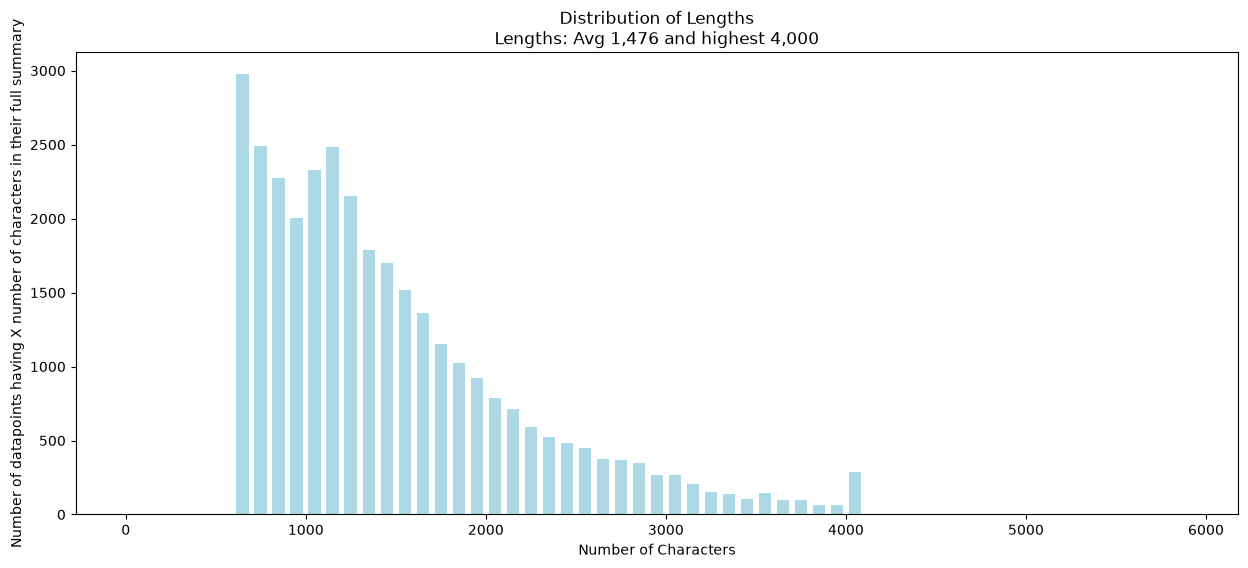

In [ ]:
# histogram (distribution of characters in full summary after de-duplication)

lengths = [len(item.full) for item in items]
plt.figure(figsize=(15,6))
plt.title(f'Distribution of Lengths\nLengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,.0f}')
plt.xlabel('Number of Characters')
plt.ylabel('Number of datapoints having X number of characters in their full summary')
plt.hist(lengths, rwidth=0.7, color='lightblue', bins=range(0,6000,100))
plt.show()

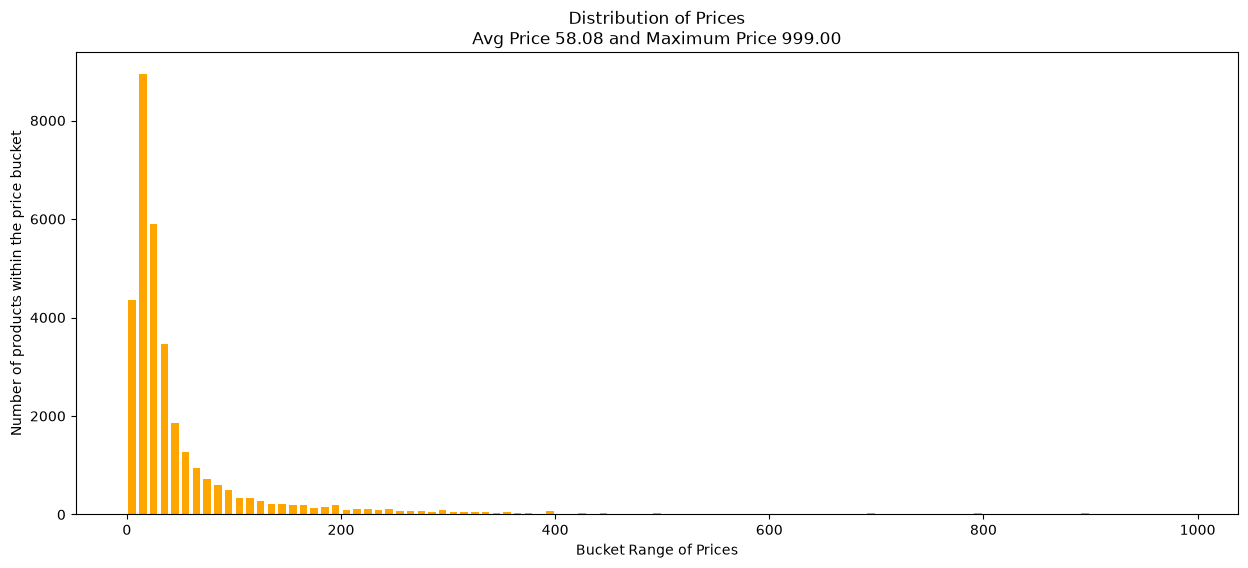

In [94]:
# histogram (distribution of prices after de-duplication)

prices = [item.price for item in items]
plt.figure(figsize=(15,6))
plt.title(f'Distribution of Prices\nAvg Price {sum(prices)/len(prices):,.2f} and Maximum Price {max(prices):,.2f}')
plt.xlabel('Bucket Range of Prices')
plt.ylabel('Number of products within the price bucket')
plt.hist(prices, rwidth=0.7, color='orange', bins=range(0,1000,10))
plt.show()

Counter({'Appliances': 32721})

No of categories in the dataset 1
Available Categories are: ['Appliances']


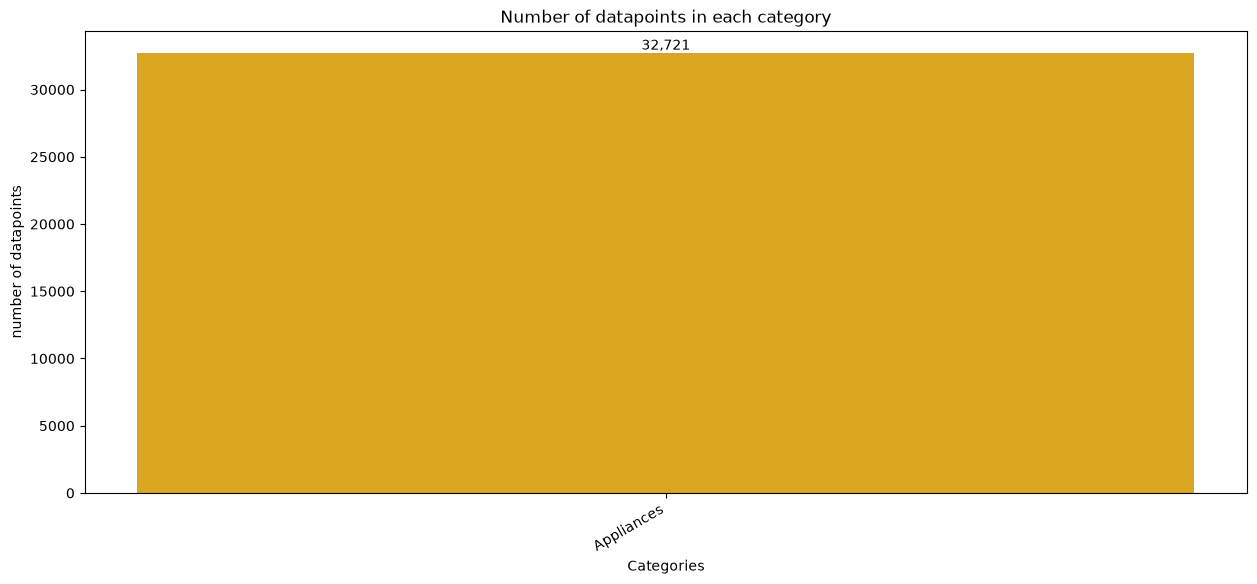

In [ ]:
# to count the number of datapoints based on category
# since we are using simple dataset having 1 category, the bar chart is simple
# but this is best suitable if we have the orginal big dataset with multiple categories

from collections import Counter

category_counter = Counter([item.category for item in items])
print(f'{category_counter}\n')
print(f'No of categories in the dataset {len(category_counter)}')

categories = category_counter.keys()
print(f'Available Categories are: {[category for category in categories]}')

counts = [category_counter[category] for category in categories]

plt.figure(figsize=(15,6))
plt.title('Number of datapoints in each category')
plt.xlabel('Categories')
plt.ylabel('number of datapoints')
plt.bar(categories, counts, color='goldenrod')
plt.xticks(rotation=30, ha='right')             # this line tilts the x-label value to 30% above from right

for i, v in enumerate(counts):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom')      # this line adds the count value for each bar just above it with center alignment

plt.show()




In [145]:
# in the big dataset, some categories have more number of datapoints compared to others
# this make the model while training to get biased towards the categories that has more number of datapoints
# so to standardize this, we will limit the categories having more no. of datapoints to have few
# and also standardize the prices to value from 0 to 1 using Min-Max Normalization as few products are too costly and few are cheap, and this will make the model to be biased towards certain products

np.random.seed(42)

SIZE = 8200                  # selecting 8200 datapoints randomly from the entire dataset

prices = np.array([item.price for item in items], dtype=float)
categories = np.array([item.category for item in items])

# normalizing the prize (0 to 1)
normalized_prices = (prices-prices.min())/(prices.max()-prices.min()+1e-9)        # we are adding a small denominator 10^-9 to avoid divide by zero error

print(f'Normalized Prices are {normalized_prices}')

weights = normalized_prices**2                  # making the normalized prices much smaller
print(weights)

# if the Tools_and_Home_Improvement category has high biased prices, we further reduce to 1/2
weights[categories=="Tools_and_Home_Improvement"] *= 0.5
print(weights)

# if the Automotive category has the very high biased prices
weights[categories=="Automotive"] *= 0.05
print(weights)

# weighted sampling i.e., converting all the datapoints price weights into probabilities such that some of all probabilities = 1
weighted_sample = weights / weights.sum()
print(weighted_sample)

# select random 8200 datapoints randomly without replacing the already picked datapoint, 
# p=weighted_sample indicates, the probabilty of piciking a datapoint directly depends on its weighted probabiliy
# i.e., a datapoint with 0.1% weighted probability will have probability of 0.1 to get picked
index = np.random.choice(len(items), size=SIZE, replace=False, p=weighted_sample)

# sampled_data
sample = [items[idx] for idx in index]

print(f'Number of datapoints after standardizing and sampling are {len(sample)}')
print(type(sample))
print(type(sample[0]))


Normalized Prices are [0.02092415 0.03495375 0.02292838 ... 0.01491146 0.0509475  0.04457405]
[0.00043782 0.00122176 0.00052571 ... 0.00022235 0.00259565 0.00198685]
[0.00043782 0.00122176 0.00052571 ... 0.00022235 0.00259565 0.00198685]
[0.00043782 0.00122176 0.00052571 ... 0.00022235 0.00259565 0.00198685]
[9.41456802e-07 2.62719532e-06 1.13045024e-06 ... 4.78129204e-07
 5.58149439e-06 4.27237108e-06]
Number of datapoints after standardizing and sampling are 8200
<class 'list'>
<class 'pricer.items.Item'>


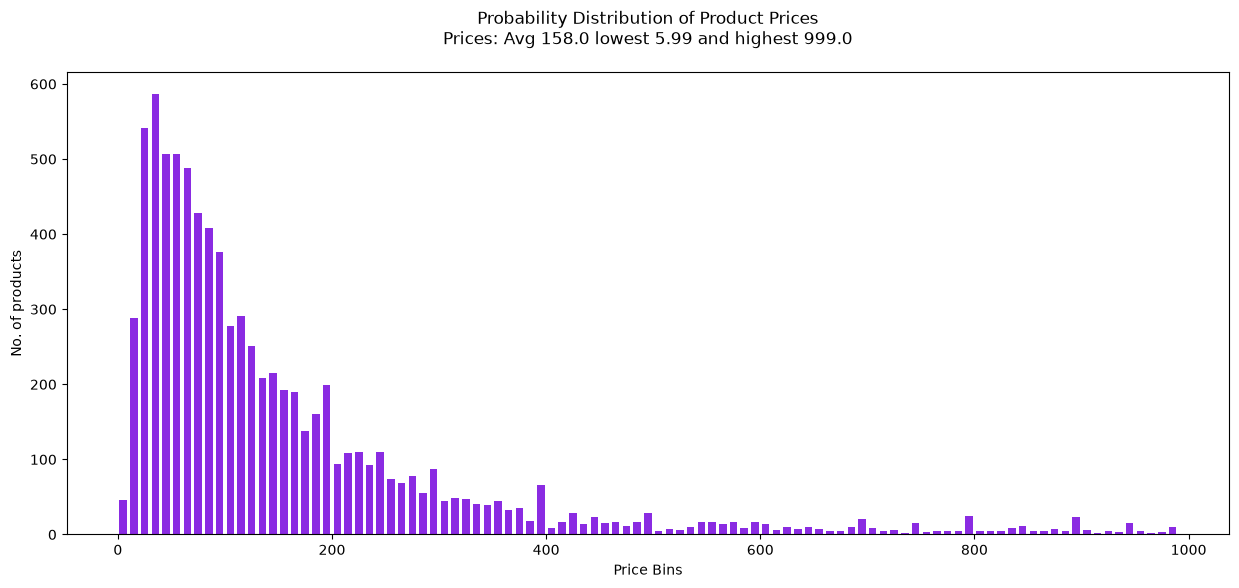

In [146]:
# histogram (probabilty distribution of products based on price of the items)

prices = [item.price for item in sample]
plt.figure(figsize=(15,6))
plt.title(f'Probability Distribution of Product Prices\nPrices: Avg {sum(prices)/len(prices):,.1f} lowest {min(prices):,} and highest {max(prices):,}\n')
plt.xlabel('Price Bins')
plt.ylabel('No. of products')
plt.hist(prices, rwidth=0.7, color='blueviolet', bins=range(0,1000,10))
plt.show()

In [148]:
# shuffling the sample again

random.seed(42)
random.shuffle(sample)

Counter({'Appliances': 8200})

No of categories in the dataset 1
Available Categories are: ['Appliances']


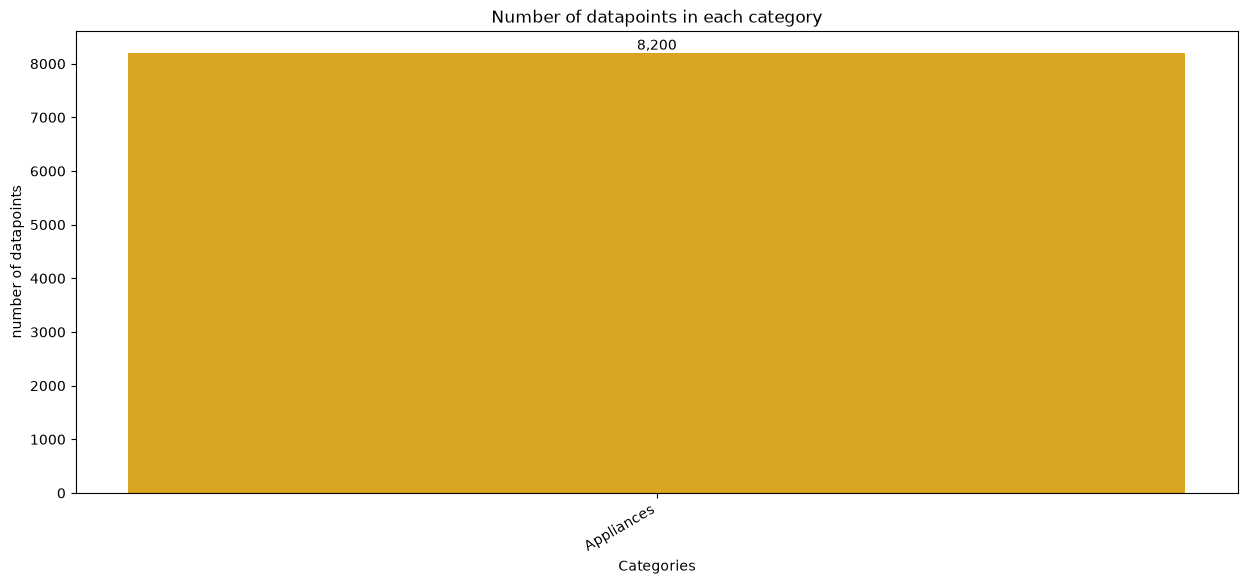

In [ ]:
# Complete overview after sampling and reshuffling

from collections import Counter

category_counter = Counter([item.category for item in sample])
print(f'{category_counter}\n')
print(f'No of categories in the dataset {len(category_counter)}')

categories = category_counter.keys()
print(f'Available Categories are: {[category for category in categories]}')

counts = [category_counter[category] for category in categories]

# Bar chart by category
plt.figure(figsize=(15,6))
plt.title('Number of datapoints in each category')
plt.xlabel('Categories')
plt.ylabel('number of datapoints')
plt.bar(categories, counts, color='goldenrod')
plt.xticks(rotation=30, ha='right')             

for i, v in enumerate(counts):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom')      # this line adds the count value for each bar just above it with center alignment

plt.show()


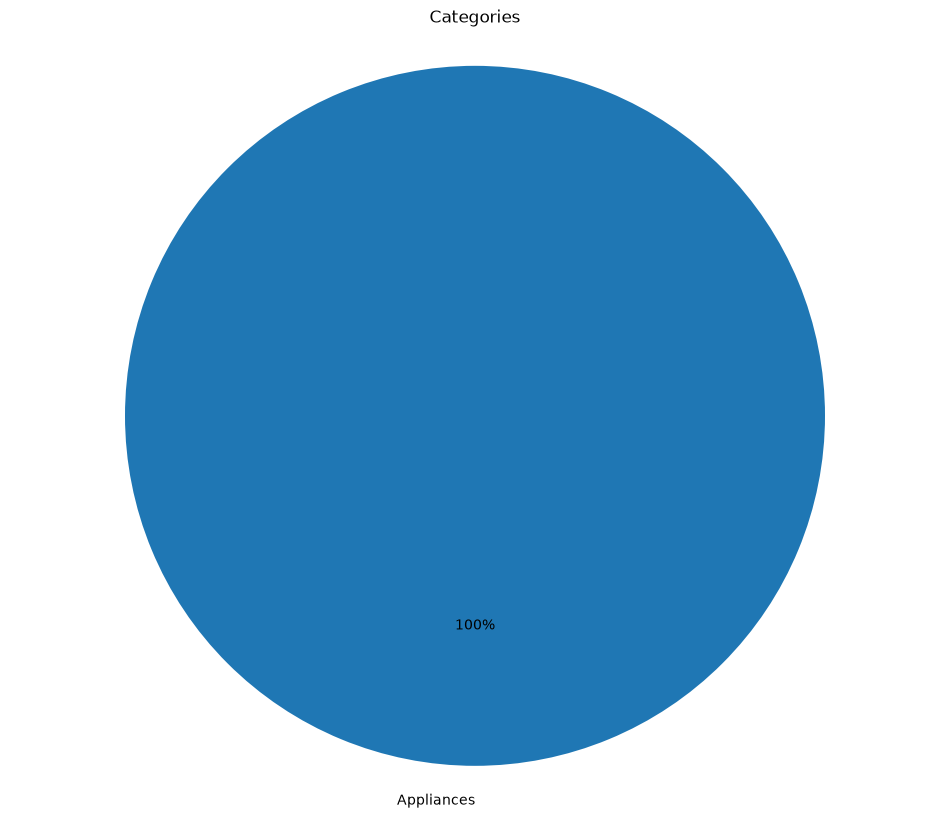

In [ ]:
# pie chart

plt.figure(figsize=(12, 10))
plt.pie(counts, labels=categories, autopct='%1.0f%%', startangle=90)
# autopct displays the percentage value along percentage symbol
# startangle start the pie from 12'o clock instead of 3'o clock
plt.title('Categories')
plt.axis('equal')               # makes height and width equal
plt.show()


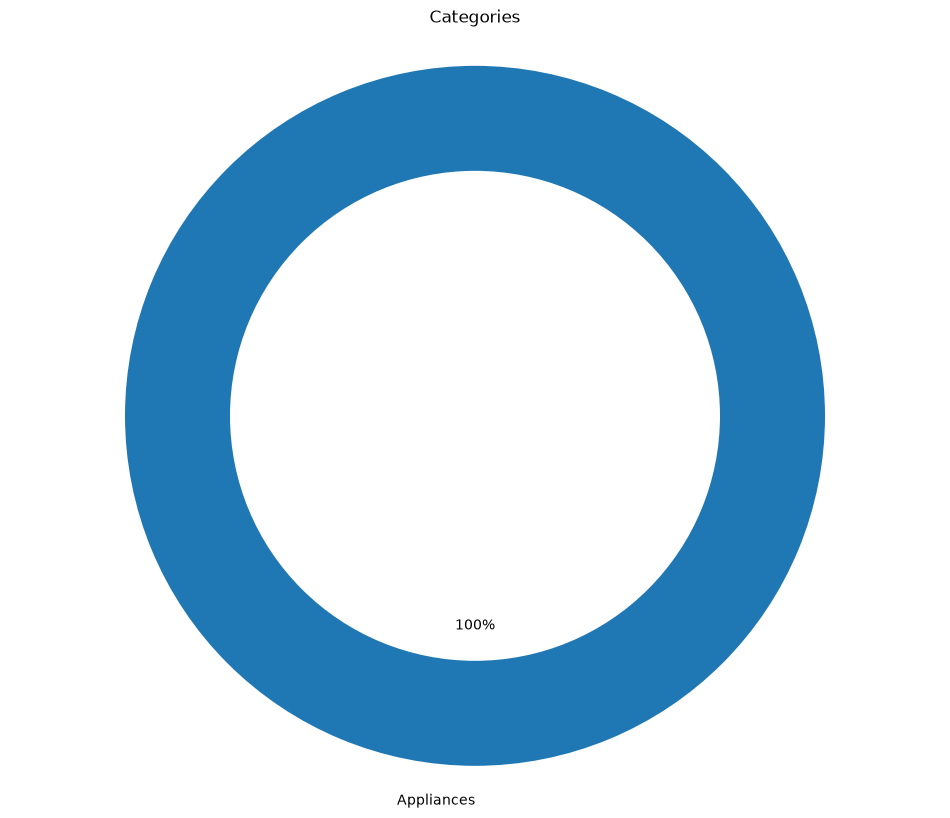

In [ ]:
# donut chart

plt.figure(figsize=(12, 10))
plt.pie(counts, labels=categories, autopct='%1.0f%%', startangle=90)
# autopct displays the percentage value along percentage symbol
# startangle start the pie from 12'o clock instead of 3'o clock

# inner circle
center_circle = plt.Circle((0,0), 0.7, fc='white')
fig = plt.gcf()
fig.gca().add_artist(center_circle)

plt.title('Categories')
plt.axis('equal')
plt.show()


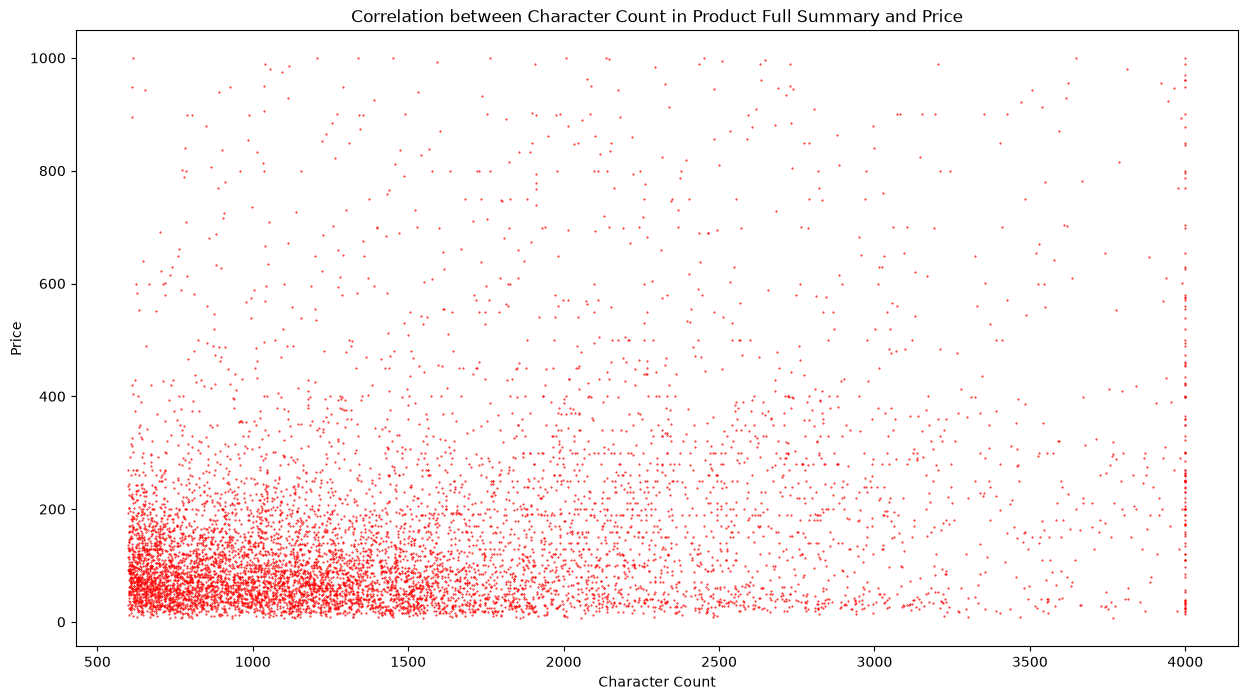

In [156]:
# Scatter plot to see how the price varies with character count

prices = [item.price for item in sample]
sizes = [len(item.full) for item in sample]

# Scatter plot
plt.figure(figsize=(15,8))
plt.scatter(sizes, prices, s=0.2, color='red')

plt.xlabel('Character Count')
plt.ylabel('Price')
plt.title('Correlation between Character Count in Product Full Summary and Price')
plt.show()

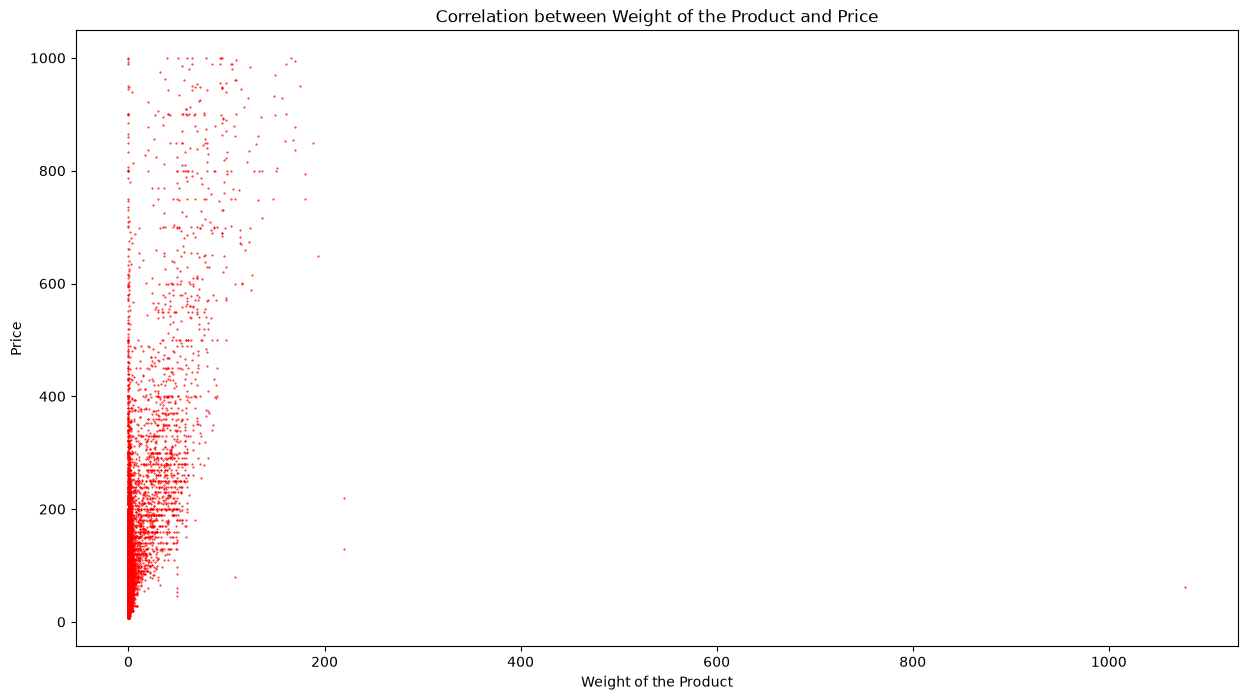

In [157]:
# Scatter plot to see how price vary with weight of the product

prices = [item.price for item in sample]
weights = [item.weight for item in sample]

# Scatter plot
plt.figure(figsize=(15,8))
plt.scatter(weights, prices, s=0.2, color='red')

plt.xlabel('Weight of the Product')
plt.ylabel('Price')
plt.title('Correlation between Weight of the Product and Price')
plt.show()

#### Pushing the Dataset to HuggingFace Hub

In [ ]:
# pushing both full dataset and lite dataset into HuggingFace Hub

username = 'lalam0'
full = f"{username}/items_raw_full"
lite = f"{username}/items_raw_lite"

train = sample[:800_000]
val = sample[800_001:810_000]
test = sample[810_001:]

Item.push_to_hub(full, train, val, test)

train_lite = train[:20_000]
val_lite = val[:1_000]
test_lite = test[:1_000]

Item.push_to_hub(lite, train_lite, val_lite, test_lite)